# MD Einfügen

In [29]:
#Imports der benötigten Pakete
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#Einlesen der CSV-Datei
data = pd.read_csv(r'C:\Users\nicob\DaBi-Projektarbeit\Abgabe 1\DABI2_Projekt1.csv')
data


,Unnamed: 0,rate,DateTime,KWH,meters
0,0,Std,2011-11-23 09:00:00.0000000,0.355,1
1,1,Std,2011-11-23 09:30:00.0000000,0.414,1
2,2,Std,2011-11-23 10:00:00.0000000,0.698,4
3,3,Std,2011-11-23 10:30:00.0000000,0.455,4
4,4,Std,2011-11-23 11:00:00.0000000,0.670,5
...,...,...,...,...,...
80685,80685,ToU,2014-02-27 22:00:00.0000000,302.767,1026
80686,80686,ToU,2014-02-27 22:30:00.0000000,286.752,1026
80687,80687,ToU,2014-02-27 23:00:00.0000000,254.521,1026
80688,80688,ToU,2014-02-27 23:30:00.0000000,211.434,1026


In [30]:
# Erster Blick auf die Daten
data.head()
#Daten bereinigen und in das richtige Format bringen
data['DateTime'] = pd.to_datetime(data['DateTime'], format='mixed')


# Aufgabe 1: 
## Für die Abgabe 3 war eine Änderung der Aufgabe 1 bei der STL zerlegung nötig
Prüfen Sie den Energieverbrauch auf Trends und Periodizität, trennen Sie die verschiedenen Bestandteile und visualisieren Sie sie geeigneter Weise.

Text(0.5, 1.0, 'Gesamtenergieverbrauch über die Zeit')

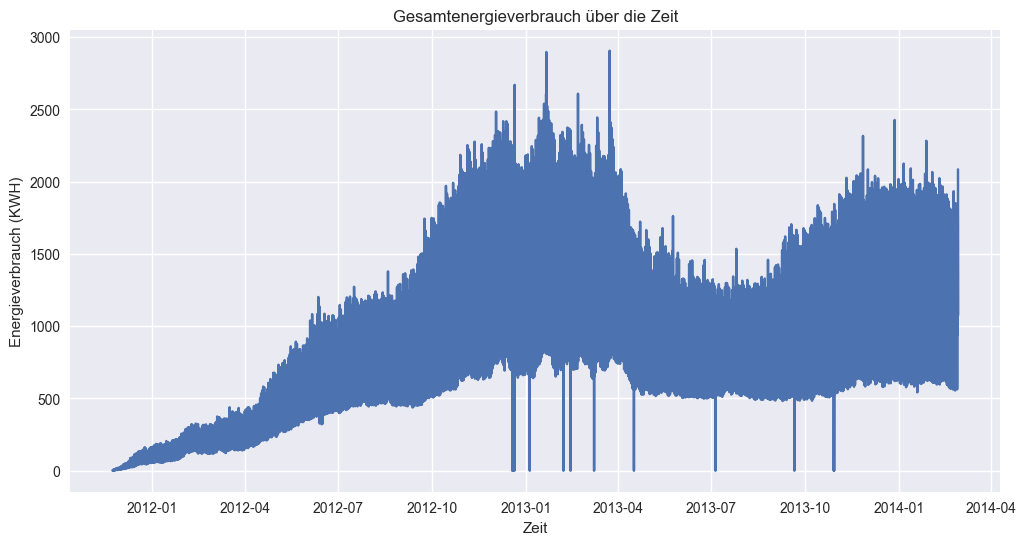

In [31]:
#Visualisierung des Energieverbrauchs über die Zeit
data_total = data.groupby('DateTime')['KWH'].sum()
plt.figure(figsize=(12, 6))
plt.plot(data_total)
plt.xlabel("Zeit")
plt.ylabel("Energieverbrauch (KWH)")
plt.title("Gesamtenergieverbrauch über die Zeit")

### Interpretation 
Die Zeitreihe zeigt einen insgesamt steigenden Energieverbrauch im Jahr 2012, der Anfang 2013 seinen Höhepunkt erreicht. Anschließend ist ein deutlicher Rückgang zu erkennen, bevor der Verbrauch im weiteren Verlauf wieder moderat ansteigt. Über den gesamten Zeitraum hinweg sind starke kurzfristige Schwankungen sichtbar, was auf eine ausgeprägte periodische Struktur hindeutet. Diese regelmäßigen Schwankungen lassen sich plausibel durch tägliche Verbrauchsmuster erklären. Zudem treten einzelne starke Einbrüche im Verbrauch auf, die auf Ausreißer oder Messfehler hindeuten könnten. Insgesamt weist die Zeitreihe sowohl einen klaren Trend als auch saisonale Effekte auf und ist daher nicht stationär. Eine Zerlegung in Trend, saisonale Komponenten und Residuen ist notwendig, um diese unterschiedlichen Einflüsse getrennt zu analysieren und die Zeitreihe besser modellieren zu können.

In [32]:
#Zeitstempel als Index setzen
data.reset_index(inplace=True)
data.set_index('DateTime', inplace=True)

## Korrektur Aufgabe 1 (STL-Zerlegung)
Die STL-Zerlegung wurde ursprünglich auf `data["KWH"]` angewendet, was denselben 
Strukturfehler wie bei Aufgabe 4 enthält: pro Zeitstempel existieren zwei Zeilen 
(Std + ToU), wodurch `period=48` nicht zur tatsächlichen Tagesperiodizität passt 
(96 Zeilen/Tag statt 48). Korrigiert auf `data_total` (Gesamtverbrauch, eine Zeile 
pro Zeitstempel) – konsistent mit der Aufgabenstellung ("Gesamtverbrauch aus allen 
Stromtarifen").

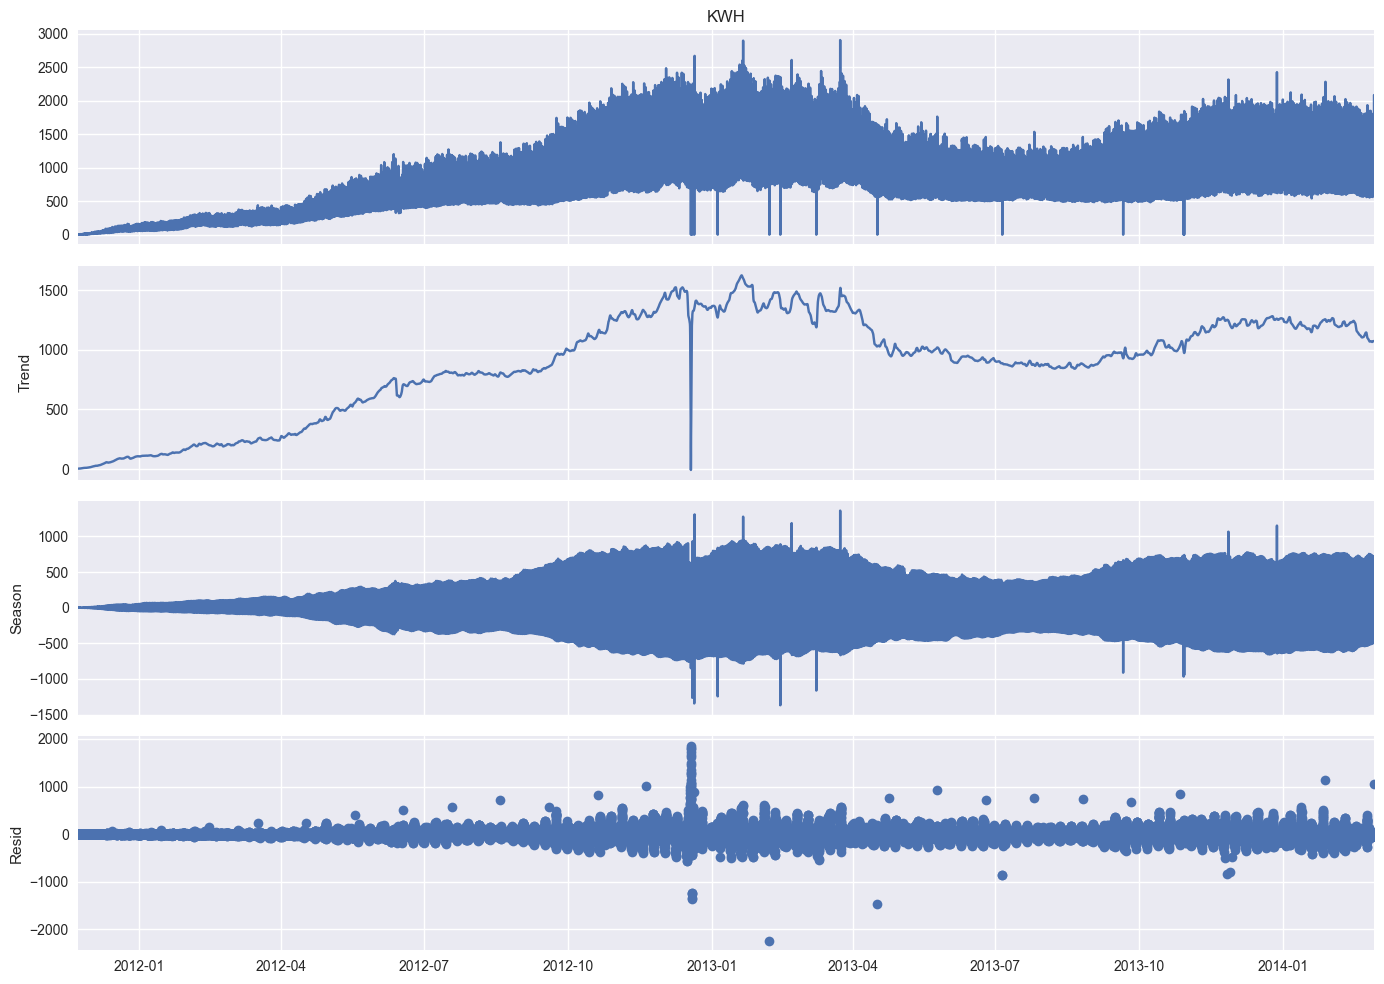

In [34]:
#STL- Zerlegung durchführen um periodische Muster und Trends zu identifizieren
from statsmodels.tsa.seasonal import STL
stl= STL(data_total,period=48, robust=True) #STL auf ganze Daten anwenden, period=48 da 48 Zeitstempel pro Tag (30min Intervalle)
result = stl.fit()

result.trend
result.seasonal
result.resid

#Visualisierung der Bestandteile
plt.style.use("seaborn-v0_8")
plt.rcParams.update({'font.size': 12})

fig = result.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

### 1. Originalzeitreihe (KWH, oberer Plot)

Der Gesamtverbrauch zeigt einen deutlichen Anstieg von Anfang 2012 bis zum Peak 
Anfang 2013 (ca. 2500 KWH), gefolgt von einem Rückgang und einer erneuten 
Stabilisierung auf ca. 1500 KWH. Die dichte Füllung des Plots zeigt die starken 
kurzfristigen Schwankungen durch das tägliche Verbrauchsmuster (Tag/Nacht-Zyklus). 
Mehrere scharfe Einbrüche Richtung 0 sind sichtbar – diese Ausreißer werden in 
den Residuen genauer untersucht.

### 2. Trendkomponente (Trend, zweiter Plot)

Der geglättete Langzeitverlauf zeigt drei klare Phasen:
- **Anstieg** (2012): kontinuierliches Wachstum von ~0 auf ~1500 KWH, 
  vermutlich durch wachsende Anzahl angeschlossener Verbraucher (`meters`)
- **Peak und Einbruch** (Anfang 2013): kurzer scharfer Einbruch auf ~0, 
  danach Rückgang auf ~800 KWH – wahrscheinlich eine Datenlücke/Messausfall
- **Erholung** (2013-2014): erneuter Anstieg auf ~1200 KWH

### 3. Saisonale Komponente (Season, dritter Plot)

Die Saisonalität zeigt das tägliche Verbrauchsmuster (period=48, d.h. 48 
Halbstunden-Intervalle pro Tag). Auffällig ist die **wachsende Amplitude** im 
Zeitverlauf: Anfang 2012 noch fast null (wenige angeschlossene Verbraucher), 
steigt sie bis 2013 auf ±1000 KWH an. Dies ist ein Hinweis darauf, dass die 
saisonalen Effekte nicht konstant sind – ein additives Modell (wie STL) ist 
daher nur eine Näherung; ein multiplikatives Modell könnte besser passen.
Die scharfen Spikes in der Saisonalität korrespondieren mit den Ausreißern 
im Originalsignal.

### 4. Residuen (Resid, unterer Plot)

Nach Entfernung von Trend und Saisonalität verbleiben die Residuen. Diese 
streuen überwiegend zufällig um null, mit Ausnahme von:
- **Starke Ausreißer um Ende 2012/Anfang 2013**: Residuen von bis zu ±2000 KWH, 
  zeitlich deckungsgleich mit dem Trendeinbruch – deutet auf Datenlücken 
  oder Messfehler hin, nicht auf ein Modellproblem
- **Vereinzelte größere Residuen** in 2013-2014 (~±1000 KWH): könnten auf 
  unregelmäßige Ereignisse (Feiertage, Wetterereignisse) hindeuten

Abgesehen von diesen Ausreißern zeigen die Residuen kein offensichtlich 
regelmäßiges Muster mehr – Trend und Saisonalität wurden erfolgreich separiert.

# Aufgabe 2
Ermitteln Sie die Autokorrelationen und partiellen Autokorrelationen der Zeitreihe.

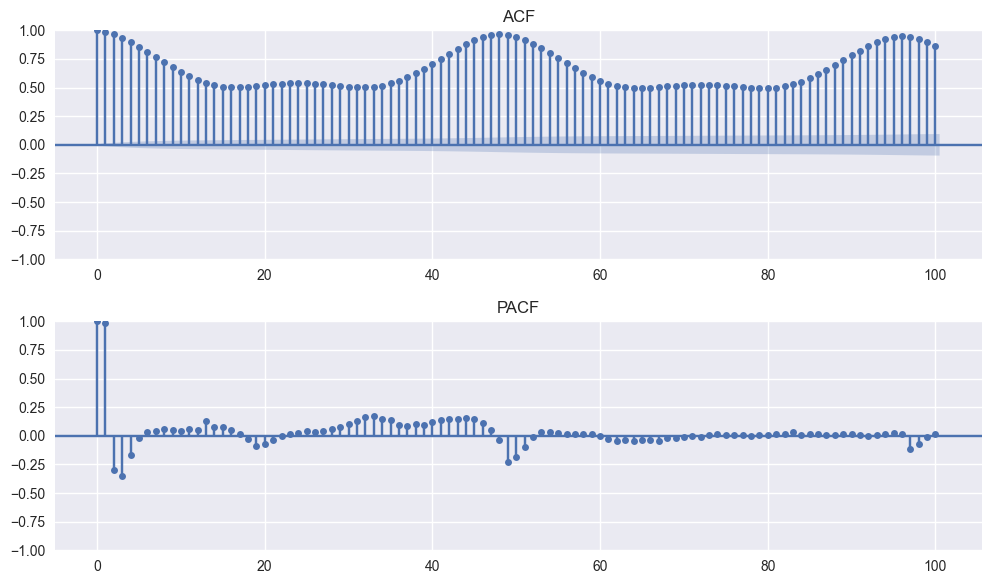

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ACF und PACF
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(data_total, lags=100, ax=axes[0])
axes[0].set_title("ACF")

plot_pacf(data_total, lags=100, ax=axes[1])
axes[1].set_title("PACF")

plt.tight_layout()
plt.show()


### Interpretation
Die Autokorrelationsfunktion (ACF) zeigt über viele Lags hinweg hohe Werte und eine deutlich erkennbare wellenförmige Struktur. Besonders auffällig sind die regelmäßigen Peaks, insbesondere bei etwa Lag 48 und dessen Vielfachen, was auf eine ausgeprägte tägliche Periodizität in der Zeitreihe hinweist. Zudem fällt die Autokorrelation nur sehr langsam ab, was auf einen vorhandenen Trend und damit Nicht-Stationarität hindeutet.

Die partielle Autokorrelationsfunktion (PACF) zeigt einen starken Ausschlag bei Lag 1, was auf eine starke kurzfristige Abhängigkeit zwischen aufeinanderfolgenden Beobachtungen hinweist. Danach treten kleinere, aber strukturierte Ausschläge auf, insbesondere im Bereich der saisonalen Lags. Dies deutet darauf hin, dass neben kurzfristigen auch saisonale Einflüsse eine Rolle spielen.

Insgesamt bestätigen ACF und PACF, dass die Zeitreihe sowohl Trend- als auch saisonale Komponenten enthält und somit nicht stationär ist.

### Aufgabe 3: Überprüfung der Eliminierung trivialer Muster

Zur Beurteilung, ob die wesentlichen Muster der Zeitreihe durch die Zerlegung entfernt wurden, werden insbesondere die Residuen der STL-Zerlegung betrachtet. Idealerweise sollten diese keine systematischen Strukturen mehr aufweisen und sich wie weißes Rauschen verhalten.

Die ursprüngliche Zeitreihe zeigt eine ausgeprägte Autokorrelation sowie klare periodische Muster, insbesondere in Form regelmäßiger Peaks in der Autokorrelationsfunktion, was auf eine starke saisonale Komponente (z. B. tägliche Zyklen) hinweist.

Nach der Zerlegung wurden Trend und saisonale Effekte weitgehend isoliert. Die Analyse der Residuen zeigt jedoch weiterhin Auffälligkeiten, insbesondere in Form von Ausreißern und teilweise erhöhter Streuung. Dies deutet darauf hin, dass die Residuen nicht vollständig frei von Struktur sind.

Eine vollständige Eliminierung der trivialen Muster liegt somit nicht vor. Mögliche Gründe hierfür sind zusätzliche saisonale Effekte (z. B. wöchentliche Muster) oder nicht berücksichtigte Einflussfaktoren. Insgesamt lässt sich festhalten, dass die Zerlegung die wichtigsten Komponenten identifiziert, jedoch noch Reststrukturen in den Residuen verbleiben.

# Fehleranalyse für Ansatz in Aufgabe 4

In [43]:
# Fehleranalyse warum auf data falsch war
print("Letzte Std-Zeilen und erste ToU-Zeilen mit lag_1:")
grenze_idx = data[data['rate'] == 'Std'].index[-3:].tolist() + \
             data[data['rate'] == 'ToU'].index[:3].tolist()

temp = data.loc[grenze_idx][['rate', 'KWH']].copy()
temp['lag_1'] = data['KWH'].shift(1).loc[grenze_idx]
print(temp)


Letzte Std-Zeilen und erste ToU-Zeilen mit lag_1:
                    rate          KWH        lag_1
DateTime                                          
2014-02-27 23:00:00  Std  1003.569000  1135.357001
2014-02-27 23:00:00  ToU   254.521000   286.752000
2014-02-27 23:30:00  Std   862.188001  1003.569000
2014-02-27 23:30:00  ToU   211.434000   254.521000
2014-02-28 00:00:00  Std  1727.588000   862.188001
2014-02-28 00:00:00  ToU   356.944000   211.434000
2011-11-23 09:00:00  Std     0.355000          NaN
2011-11-23 09:00:00  ToU     0.214000  1727.588000
2011-11-23 09:30:00  Std     0.414000     0.355000
2011-11-23 09:30:00  ToU     0.147000     0.214000
2011-11-23 10:00:00  Std     0.698000     0.414000
2011-11-23 10:00:00  ToU     0.222000     0.147000


## Fehleranalyse: Ursache des negativen R²

### Nachweis der fehlerhaften Datenstruktur

Der ursprüngliche Ansatz verwendete `data["KWH"]` für alle `.shift()`-Operationen 
(Lags und Target). `data` ist jedoch **blockweise sortiert** – erst alle Std-Zeilen 
(2011-2014), dann alle ToU-Zeilen (2011-2014). Pro Zeitstempel existieren dabei 
**zwei Zeilen** (eine für `Std`, eine für `ToU`).

### Konkreter Beweis

Der Output der Fehleranalyse zeigt:

| DateTime | rate | KWH | lag_1 |
|---|---|---|---|
| 2014-02-28 00:00:00 | Std | 1727.588 | 862.188 |
| **2011-11-23 09:00:00** | **ToU** | **0.214** | **1727.588** |
| 2011-11-23 09:30:00 | ToU | 0.147 | 0.214 |

Die erste ToU-Zeile (November 2011, 0.214 KWH) bekommt als `lag_1` den letzten 
Std-Wert (Februar 2014, **1727.588 KWH**) – ein Zeitsprung von über **2 Jahren**.

### Folge für das Modell

- Lag/Target-Paare sind an der Blockgrenze komplett sinnlos zugeordnet
- Das Modell lernt auf systematisch falschen Input/Output-Paaren
- Das gelernte lineare Verhältnis hat keine echte Vorhersagekraft
- Auf den Testdaten schlechter als der bloße Mittelwert → **negatives R²**

### Lösung

Aggregation auf `data_total` (ein Wert pro Zeitstempel, Gesamtverbrauch Std+ToU):
- Korrekte zeitliche Sortierung, kein Blocksprung
- `.shift()` entspricht echten zeitlichen Verschiebungen
- **R² steigt von negativ auf 0.48 bevor neue Features eingebaut wurden**

# Aufgabe 4
## Änderungen gegenüber dem ursprünglichen Ansatz

### Datenbasis
Das Modell wurde auf `data_total` (aggregierter Gesamtverbrauch, eine Zeile pro 
Zeitstempel) umgestellt. Die Fehleranalyse (siehe G8) hat gezeigt, dass die 
ursprüngliche Verwendung von `data["KWH"]` durch die blockweise Sortierung 
(Std/ToU) zu systematisch falschen Lag/Target-Zuordnungen führte → negatives R².

### Zusätzliche Features
- **`hour_sin`/`hour_cos`** statt roher Stundenzahl: zyklische Kodierung der 
  Tageszeit, damit das lineare Modell den Übergang 23→0 Uhr korrekt abbildet
- **`lag_36`**: Verbrauchswert zur exakt gleichen Tageszeit wie der Zielwert, 
  einen Tag früher (36+12=48 Schritte=24h). Nutzt die in Aufgabe 2 (ACF) 
  identifizierte starke tägliche Periodizität gezielt aus – Korrelation 
  mit Target: 0.9716
- **`hour_sin_weekend`/`hour_cos_weekend`**: Interaktionsterme, die das 
  unterschiedliche Tagesmuster zwischen Wochentag und Wochenende abbilden 
  (siehe Aufgabe 6)
- **`rolling_mean_48`**: Tagesdurchschnitt als Trend-Feature, um den 
  langfristigen Trend (66% der Gesamtvarianz) besser einzufangen

''' Erstellen Sie ein lineares Prognosemodell, das den Stromverbrauch jeweils 6
Stunden in die Zukunft prognostiziert. '''

In [7]:
data_total = data_total.to_frame(name="KWH") #KWH in DataFrame umwandeln, damit wir die Zeitstempel als Index behalten und die Spalten verwenden können

# target definieren
data_total["target"] = data_total["KWH"].shift(-12)

In [ ]:
# Feature erstellen

data_total["lag_1"] = data_total["KWH"].shift(1)
data_total["lag_2"] = data_total["KWH"].shift(2)
data_total["lag_12"] = data_total["KWH"].shift(12)   # 6 Stunden zurück
data_total["lag_24"] = data_total["KWH"].shift(24)   # 1 Tag zurück
data_total["lag_48"] = data_total["KWH"].shift(48)
data_total["hour"] = data_total.index.hour
data_total["dayofweek"] = data_total.index.dayofweek
data_total["is_weekend"] = (data_total["dayofweek"] >= 5).astype(int)
data_total["rolling_mean_6"] = data_total["KWH"].shift(1).rolling(6).mean() #leichte Glättung der input daten

#features einbauen Neu
data_total["hour_sin"] = np.sin(2 * np.pi * data_total["hour"] / 24) #zyklische Kodierung der Stunde
data_total["hour_cos"] = np.cos(2 * np.pi * data_total["hour"] / 24) #zyklische Kodierung der Stunde

data_total["week_sin"] = np.sin(2 * np.pi * data_total["dayofweek"] / 7) #zyklische Kodierung des Wochentags
data_total["week_cos"] = np.cos(2 * np.pi * data_total["dayofweek"] / 7) #zyklische Kodierung des Wochentags

data_total["lag_36"] = data_total["KWH"].shift(36) # 18h zurück von t, aber 24h vor dem Zielwert (target=t+12) → gleiche Tageszeit wie Zielwert, einen Tag früher

data_total["hour_sin_weekend"]= data_total["hour_sin"] * data_total["is_weekend"] # Interaktionsterm zwischen Stunde und Wochenende
data_total["hour_cos_weekend"]= data_total["hour_cos"] * data_total["is_weekend"] # Interaktionsterm zwischen Stunde und Wochenende

data_total["rolling_mean_48"] = data_total["KWH"].shift(1).rolling(48).mean() # stärkere Glättung der input daten

In [9]:
# missing values entfernen
data_total = data_total.dropna()

In [10]:
print(data_total[["target","lag_36","lag_48","lag_1"]].corr())

          target    lag_36    lag_48     lag_1
target  1.000000  0.971672  0.561888  0.538135
lag_36  0.971672  1.000000  0.565660  0.536405
lag_48  0.561888  0.565660  1.000000  0.963996
lag_1   0.538135  0.536405  0.963996  1.000000


In [11]:
#train und test split erstellen

split_idx = int(len(data_total) * 0.8)

train = data_total.iloc[:split_idx]
test = data_total.iloc[split_idx:]

In [13]:
#features und target definieren

features = ["lag_1", "lag_2", "lag_12", "lag_24", "lag_48", "hour_sin", "hour_cos", "week_sin", "week_cos", "is_weekend", "rolling_mean_6", "lag_36", "hour_sin_weekend", "hour_cos_weekend", "rolling_mean_48"]

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

In [14]:
# lineares Modell trainieren

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# Vorhersage machen

y_pred = model.predict(X_test)

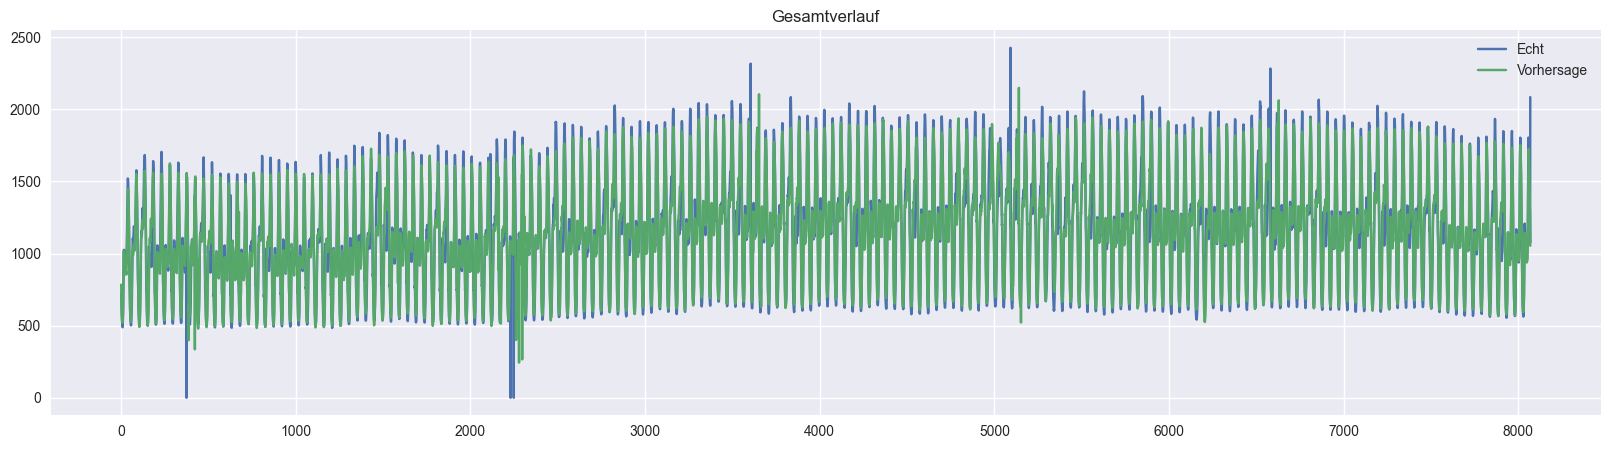

In [16]:
# Visualisiserung

plt.figure(figsize=(20,5))

plt.plot(y_test.values, label="Echt")
plt.plot(y_pred, label="Vorhersage")

plt.title("Gesamtverlauf")
plt.legend()

plt.show()

## Ergebnis: Vorhersage vs. Tatsächlicher Verbrauch

Der Plot zeigt den tatsächlichen Verbrauch (blau) und die Modellvorhersage (grün) 
über den gesamten Testzeitraum.

Das Modell folgt dem tatsächlichen Verbrauch sehr gut – das tägliche Muster 
(Tag/Nacht-Zyklus) wird zuverlässig abgebildet. Die Vorhersage liegt in den 
meisten Bereichen eng an den echten Werten.

Auffällig sind zwei starke Einbrüche (~Index 400 und ~Index 2250), bei denen 
der echte Verbrauch auf nahezu 0 fällt. Das Modell erkennt diese Einbrüche 
teilweise (grüne Kurve zeigt ebenfalls einen Rückgang), kann die volle Tiefe 
jedoch nicht vorhersagen – diese Ausreißer entsprechen den bereits in Aufgabe 1 
und 3 identifizierten Datenlücken/Messfehlern, die per Definition nicht 
modellierbar sind.



# Aufgabe 5

In [17]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

0.9245617095192398


In [44]:
#test auf overfitting

from sklearn.metrics import r2_score

r2_train = r2_score(y_train, model.predict(X_train))
r2_test  = r2_score(y_test, model.predict(X_test))

print(f"R² Train: {r2_train:.4f}")
print(f"R² Test:  {r2_test:.4f}")

R² Train: 0.9514
R² Test:  0.9246


## Ergebnis

| | Ursprünglich | Korrigiert |
|---|---|---|
| R² Test | negativ | 0.9246 |
| R² Train | – | 0.9514 |
| Overfitting | – | nicht signifikant (Δ=0.027) |

Der hohe R² ist primär auf `lag_36` zurückzuführen, was die starke tägliche 
Periodizität der Zeitreihe widerspiegelt – konsistent mit dem ACF-Peak bei 
Lag 48 aus Aufgabe 2.

In [18]:
#Zeitreihe zerlegen

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(data_total["KWH"], model="additive", period=48)

In [19]:
total_var = data_total["KWH"].var()

trend_var = result.trend.var()
seasonal_var = result.seasonal.var()
resid_var = result.resid.var()

In [20]:
print("Trend Anteil:", trend_var / total_var)
print("Saisonalität Anteil:", seasonal_var / total_var)
print("Rest:", resid_var / total_var)

Trend Anteil: 0.6607712069621056
Saisonalität Anteil: 0.1768539393303285
Rest: 0.1603322144943144


## Varianzanteile der Zeitreihe (STL-Zerlegung)

| Komponente | Anteil |
|---|---|
| Trend | 66.0% |
| Saisonalität | 17.8% |
| Rest | 16.1% |

## Einordnung

Der Trend macht mit 66% den größten Anteil der Gesamtvarianz aus. Das Modell 
erfasst diesen implizit über die Lag-Features (besonders `lag_36` und 
`rolling_mean_48`), die das aktuelle Verbrauchsniveau widerspiegeln.

Die Saisonalität (17.8%) wird durch `lag_36` besonders effektiv abgebildet: 
`lag_36` entspricht der gleichen Tageszeit wie der Zielwert, einen Tag früher 
(Abstand lag_36 → target = 48 Schritte = 24h). Die Korrelation zwischen 
`lag_36` und `target` beträgt **0.9716** – konsistent mit dem starken ACF-Peak 
bei Lag 48 aus Aufgabe 2.

Das Modell erklärt mit R²=0.9246 mehr als Trend+Saisonalität zusammen (83.8%), 
da `lag_36` beide Komponenten gleichzeitig implizit erfasst. Der verbleibende 
nicht erklärbare Anteil (7.5%) liegt unterhalb des Rest-Anteils (16.1%) – 
ein Teil des Rauschens wird also ebenfalls durch die Lag-Features abgedeckt, 
da sich kurzfristige Abweichungen über 24h teilweise wiederholen.

# Aufgabe 6

### Der Stromversorger will beurteilen, welche Auswirkungen die zeitabhängigen Tarife haben. Untersuchen Sie, ob Sie interessante Unterschiede im Verbrauchsverhalten zwischen den Tarifen feststellen können. 

### Vergleich des Verbrauchsverhaltens zwischen den Tarifen

Für die Analyse wurden die Daten in die beiden Tarife `Std` und `ToU` aufgeteilt. Anschließend wurde der Verbrauch der beiden Gruppen grafisch verglichen und nach Uhrzeit ausgewertet, um mögliche Unterschiede im Tagesverlauf zu erkennen.

In [21]:
# Verbrauch pro Verbraucher berechnen
data["kwh_pro_meter"] = data["KWH"] / data["meters"]

In [22]:
# daten trennen

std = data[data["rate"] == "Std"]
tou = data[data["rate"] == "ToU"]

In [23]:
# durchschnittsverbrauch

std_mean = std["kwh_pro_meter"].mean()
tou_mean = tou["kwh_pro_meter"].mean()

print("Mittlerer Verbrauch pro Verbraucher:")
print("Std:", std_mean)
print("ToU:", tou_mean)

Mittlerer Verbrauch pro Verbraucher:
Std: 0.22026970050648495
ToU: 0.20434685550227089


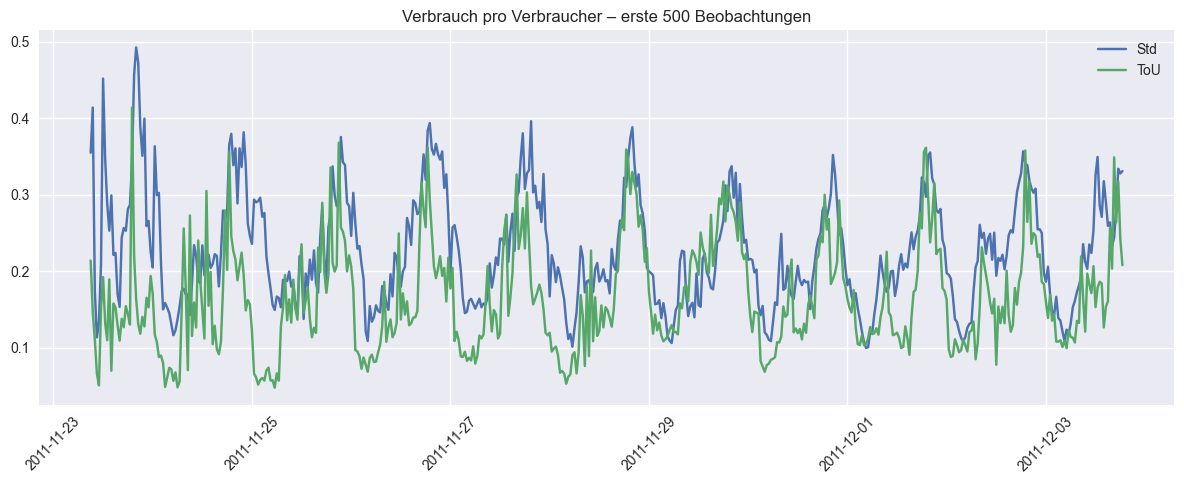

In [24]:
# Zeitverlauf der ersten 500 Beobachtungen
plt.figure(figsize=(12,5))
plt.plot(std.index[:500], std["kwh_pro_meter"].iloc[:500], label="Std")
plt.plot(tou.index[:500], tou["kwh_pro_meter"].iloc[:500], label="ToU")
plt.legend()
plt.title("Verbrauch pro Verbraucher – erste 500 Beobachtungen")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Erklärung der ersten Grafik

In der ersten Grafik sehen wir die ersten 500 beobachteten Werte des Stromverbrauchs für beide Verbrauchergruppen dargestellt. Da die Beobachtungen in 30min Intervallen statt fanden, entsprechen diese ungefähr den ersten 10 Tagen.

Wir haben hier nur die ersten 500 Werte genommen, sodass man die Grafik besser lesen und deuten kann. Sonst wäre es sehr unübersichtlich.  

## Interpretation der Ergebnisse

Der Vergleich zeigt, dass der Verbrauch im Standardtarif über fast den gesamten Zeitraum deutlich höher liegt als im variablen Strompreistarif. Beide Zeitreihen zeigen einen ähnlichen wellenförmigen Verlauf, daraus kann man schließen, dass es sich um einen zyklischen Tagesverbrauch handeln kann. 

In [25]:
# Verhalten nach Uhrzeit vergleichen

std_hour = std.groupby(std.index.hour)["kwh_pro_meter"].mean()
tou_hour = tou.groupby(tou.index.hour)["kwh_pro_meter"].mean()

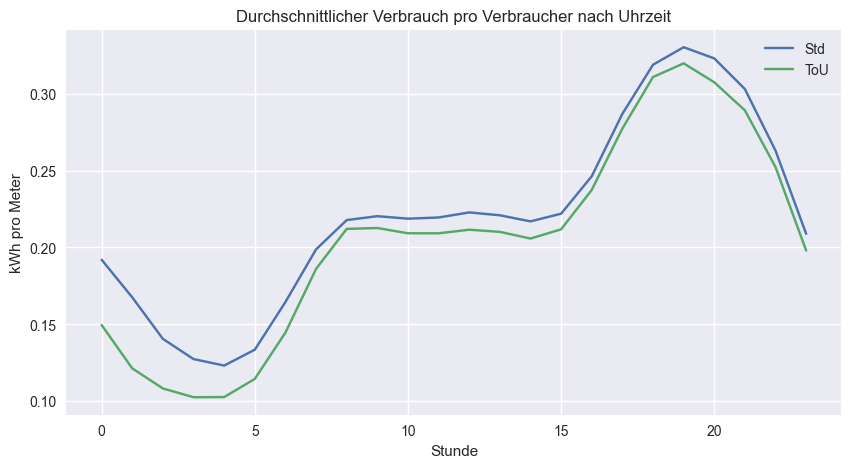

In [26]:
plt.figure(figsize=(10,5))
plt.plot(std_hour, label="Std")
plt.plot(tou_hour, label="ToU")
plt.legend()
plt.title("Durchschnittlicher Verbrauch pro Verbraucher nach Uhrzeit")
plt.xlabel("Stunde")
plt.ylabel("kWh pro Meter")
plt.show()

## Erklärung der zweiten Grafik

In der zweiten Grafik vergleichen wir den durchschnittlichen Tagesverlauf, in Abhängigkeit von der Uhrzeit, der beiden Tarifgruppen (`Std`-`ToU`). So lässt sich erkennen zu welchen Zeiten der Verbrauch besonders hoch oder niedrig ist.

## Interpretation der Ergebnisse

Auch hier zeigt sich in beiden Gruppen ein ähnlicher Tagesverlauf. In der Nacht ist er am niedrigsten und verlaufe des Tages steigt er an, bis er ungefähr um 19Uhr seinen höhepunkt errreicht. 
Die Std-Gruppe liegt hier zu jedem Zeitpunkt über der ToU-Gruppe. 
Dies Zeigt ein jeweils ähnliches Tagesmuster, aber ein insgesamt höheren Verbrauch der Standardtarifgruppe. 

In [27]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, model.predict(X_train))
r2_test  = r2_score(y_test, model.predict(X_test))

print(f"R² Train: {r2_train:.4f}")
print(f"R² Test:  {r2_test:.4f}")

R² Train: 0.9514
R² Test:  0.9246
